In [1]:
import pandas as pd
df = pd.read_csv('feature_eng_df_final.csv')

In [2]:
df.head()

,age,education,monthly_salary,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,...,affordability_ratio,credit_score_category,credit_score_numeric,combined_credit_risk,employment_tenure_category,is_long_term_employed,income_per_family_member,savings_to_income_ratio,credit_stability_score,loan_affordability_index
0,38.0,3.0,11.321777,0.641854,2.0,0.0,1.280128,3,2,0.0,...,-2.443993,Fair,2,3,Entry-level,0,3.773926,0.042580,423.623565,1.205905
1,38.0,1.0,9.975855,2.079442,4.0,1.0,-0.814566,2,1,5100.0,...,-513.331366,Good,1,2,Mid-level,1,4.987927,-0.177067,1484.721261,1.178826
2,38.0,3.0,11.363276,1.916923,0.0,2.0,-0.814566,4,3,0.0,...,-1.321418,Fair,2,2,Mid-level,1,2.840819,0.346565,1245.999698,1.111593
3,58.0,0.0,11.109473,1.163151,2.0,2.0,-0.814566,5,4,11400.0,...,-1027.461671,Good,1,1,Entry-level,0,2.221895,0.200884,796.758305,1.136398
4,48.0,3.0,10.956073,1.481605,2.0,1.0,-0.814566,4,3,9400.0,...,-859.501890,Excellent,0,0,Mid-level,0,2.739018,-0.153537,1140.835497,1.135187


In [3]:
len(df.columns)

45

In [4]:
df.select_dtypes(include='object').columns

Index(['age_group', 'credit_score_category', 'employment_tenure_category'], dtype='object')

In [5]:
# dropping credit score category since it already encoded as new column credit_score_numeric
df.drop('credit_score_category',axis=1,inplace=True)

In [6]:
#let's encode the binned age group column derived from age column in to ordinal encoder
df['age_group'].unique()
age_group_order = ['25-34','35-44', '45-54', '55-64']
from sklearn.preprocessing import OrdinalEncoder
age_group_encoder = OrdinalEncoder(categories=[age_group_order])
df['age_group'] = age_group_encoder.fit_transform(df[['age_group']])
print("after encoding df['age_group']",df['age_group'].unique())
df.drop('age',axis=1,inplace=True)

after encoding df['age_group'] [1. 3. 2. 0.]


In [7]:
#let encode binned employment experience type from year_of_employment column 
df['employment_tenure_category'].unique()
employment_order = ['Entry-level', 'Mid-level', 'Experienced']
emp_category_encoder = OrdinalEncoder(categories=[employment_order])
df['employment_tenure_category'] = emp_category_encoder.fit_transform(df[['employment_tenure_category']])
print("after encoding emp tenure category ",df['employment_tenure_category'].unique())
df.drop('years_of_employment',axis=1,inplace=True)

after encoding emp tenure category  [0. 1. 2.]


In [8]:
from sklearn.model_selection import train_test_split
X=df.drop(['emi_eligibility'],axis=1)
y=df['emi_eligibility']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(322243, 41)
(80561, 41)
(322243,)
(80561,)


In [75]:
df.columns

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'age_group', 'gender_FEMALE', 'gender_MALE',
       'marital_status_Married', 'marital_status_Single',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='ob

In [9]:
# Avoiding dummy traps
X_train.drop(['gender_MALE','marital_status_Single','employment_type_Government'],axis=1,inplace=True)
X_test.drop(['gender_MALE','marital_status_Single','employment_type_Government'],axis=1,inplace=True)

In [10]:
#Prdeciting Features
X_train.drop(['max_monthly_emi'],axis=1,inplace=True)
X_test.drop(['max_monthly_emi'],axis=1,inplace=True)

In [11]:
#dropping functional duplicates...
columns_to_drop = ['monthly_rent','school_fees','college_fees','travel_expenses','groceries_utilities','other_monthly_expenses']
X_train= X_train.drop(columns=columns_to_drop, axis=1)
X_test= X_test.drop(columns=columns_to_drop, axis=1)

In [12]:
#dropping existing loan to see it has huge impact on misclassification
X_train.drop('existing_loans',axis=1,inplace=True)
X_test.drop('existing_loans',axis=1,inplace=True)

In [13]:
print(X_train.columns)
print(len(X_train.columns))

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'family_size', 'dependents', 'current_emi_amount', 'credit_score',
       'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount',
       'requested_tenure', 'age_group', 'gender_FEMALE',
       'marital_status_Married', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='object')
30


**1 .Checking count of each categorical target variable in train data**

Reason: Checking for class imbalance


Outcome : can take a decision on whether sampling is needed or not


In [81]:
y_train.value_counts()

emi_eligibility
2.0    249061
0.0     59265
1.0     13917
Name: count, dtype: int64

In [82]:
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,classification_report,confusion_matrix,roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
# Set a tracking URI for MLflow. By default, it uses a local folder 'mlruns'.
# You can also set it to a database or a remote server.
# mlflow.set_tracking_uri("sqlite:///mlruns.db") # Example for a database

print(f"MLflow Version: {mlflow.__version__}")

MLflow Version: 3.9.0


In [14]:
training_columns = X_train.columns.tolist()

import joblib
joblib.dump(training_columns, "clf_training_columns.pkl")

['clf_training_columns.pkl']

### Training a XGBoost Classifier Model

Let's assume you have your `X_train`, `X_test`, `y_train`, `y_test` data ready from previous steps.

In [83]:
weight_combinations = [
    # (class0_weight, class1_weight, class2_weight)
    (1.0, 5.0, 0.8),   # More balanced
    (1.0, 6.0, 0.8),   
    (1.0, 7.0, 0.8),   
    (1.0, 4.0, 0.8),   # Less aggressive
    (1.0, 5.0, 0.7),   # Penalize class 2 less
    (1.0, 5.0, 0.9),   # Penalize class 2 more
]
def evaluate_weights_with_threshold(X, y, weight_configs, threshold=0.50, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for config in weight_configs:
        cv_f1_scores = []
        class_weights_dict = {0: config[0], 1: config[1], 2: config[2]}
        
        for train_idx, val_idx in skf.split(X, y):
            X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            sw = compute_sample_weight(class_weight=class_weights_dict, y=y_train_cv)
            
            model = XGBClassifier(
                objective='multi:softprob',
                num_class=3,
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                tree_method='hist', # Added for speed
                random_state=42
            )
            
            model.fit(X_train_cv, y_train_cv, sample_weight=sw, verbose=False)
            
            # --- START THRESHOLD LOGIC ---
            probs = model.predict_proba(X_val_cv)
            
            custom_preds = []
            for p in probs:
                # If Probability of Class 1 is above threshold, pick 1
                if p[1] >= threshold:
                    custom_preds.append(1.0)
                else:
                    # Otherwise, pick the higher of Class 0 or Class 2
                    custom_preds.append(0.0 if p[0] > p[2] else 2.0)
            # --- END THRESHOLD LOGIC ---

            f1 = f1_score(y_val_cv, custom_preds, average=None, labels=[1])[0]
            cv_f1_scores.append(f1)
        
        avg_f1 = np.mean(cv_f1_scores)
        std_f1 = np.std(cv_f1_scores)
        results.append((class_weights_dict, avg_f1, std_f1))
        print(f"Weights {class_weights_dict} @ Threshold {threshold}: Mean F1={avg_f1:.3f}")

    return sorted(results, key=lambda x: x[1], reverse=True)

# Test with a higher threshold to boost precision
best_configs = evaluate_weights_with_threshold(X_train, y_train, weight_combinations, threshold=0.55)

KeyboardInterrupt: 

In [84]:
# 1. Use the best weights we found
best_weights = {0: 1.0, 1: 5.0, 2: 0.9}
sample_weights = compute_sample_weight(class_weight=best_weights, y=y_train)

# 2. Configure the model with "Heavy Regularization"
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=1000,        # More trees...
    learning_rate=0.02,       # ...but slower learning (crucial for stability)
    max_depth=6,              # Shallower trees prevent memorizing noise
    
    # --- Regularization Logic ---
    reg_lambda=10.0,          # High L2 regularization
    reg_alpha=1.0,            # Added L1 regularization
    subsample=0.8,            # Use 80% of rows per tree (adds randomness)
    colsample_bytree=0.8,     # Use 80% of features per tree
    min_child_weight=5,       # Requires more evidence to create a leaf
    
    tree_method='hist',       # Efficiency for your 350k rows
    random_state=42,
    n_jobs=-1
)

# 3. Fit with Early Stopping to prevent the "Train vs Test" divergence
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-mlogloss:0.73836
[100]	validation_0-mlogloss:0.39562
[200]	validation_0-mlogloss:0.33101
[300]	validation_0-mlogloss:0.30461
[400]	validation_0-mlogloss:0.28858
[500]	validation_0-mlogloss:0.27752
[600]	validation_0-mlogloss:0.26912
[700]	validation_0-mlogloss:0.26276
[800]	validation_0-mlogloss:0.25761
[900]	validation_0-mlogloss:0.25356
[999]	validation_0-mlogloss:0.25016


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [85]:
# Make predictions
y_pred = xgb_model.predict(X_test)
# view metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("accuracy --",accuracy)
print("precision---",precision)
print("recall score---",recall)
print("f1 score.----",f1)


accuracy -- 0.8945023026029965
precision--- 0.7213407933334022
recall score--- 0.7976973311741404
f1 score.---- 0.7316746330947567


In [63]:
# Get raw probabilities
y_probs = xgb_model.predict_proba(X_test)

# Set your bar (Example: 0.55 to fix the 0.29 precision)
threshold_class1 = 0.48

custom_preds = []
for p in y_probs:
    # p is [prob_class_0, prob_class_1, prob_class_2]
    if p[1] >= threshold_class1:
        custom_preds.append(1)
    else:
        # Pick the highest between 0 and 2
        custom_preds.append(0 if p[0] > p[2] else 2)

# 5. Evaluate
print(f"Results with Threshold {threshold_class1}:")
print(classification_report(y_test, custom_preds))

Results with Threshold 0.48:
              precision    recall  f1-score   support

         0.0       0.88      0.81      0.84     14817
         1.0       0.32      0.61      0.42      3479
         2.0       0.97      0.94      0.96     62265

    accuracy                           0.90     80561
   macro avg       0.72      0.78      0.74     80561
weighted avg       0.93      0.90      0.91     80561



In [66]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.90      0.78      0.83     14817
         1.0       0.29      0.68      0.41      3479
         2.0       0.98      0.93      0.96     62265

    accuracy                           0.89     80561
   macro avg       0.72      0.80      0.73     80561
weighted avg       0.93      0.89      0.91     80561



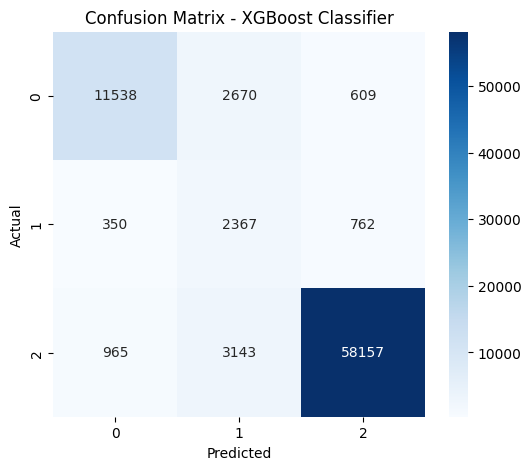

In [86]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

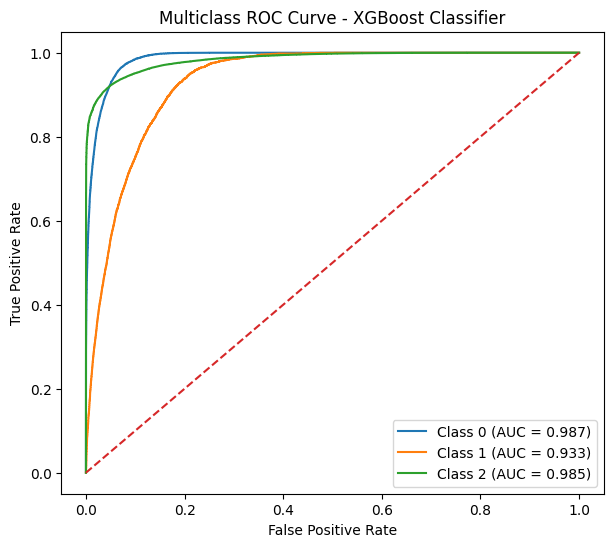

In [88]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - XGBoost Classifier")
plt.legend()
plt.show()

In [43]:
x_predict_ = xgb_model.predict(X_train)

In [44]:
# Make predictions
x_pred_prob = xgb_model.predict_proba(X_train)
# view metrics
x_accuracy = accuracy_score(y_train,x_predict_)
x_precision = precision_score(y_train, x_predict_, average='macro')
x_recall = recall_score(y_train, x_predict_, average='macro')
x_f1 = f1_score(y_train, x_predict_, average='macro')
x_roc_auc = roc_auc_score(y_train, x_pred_prob, multi_class='ovo', average='macro')
print("accuracy --",x_accuracy)
print("precision---",x_precision)
print("recall score---",x_recall)
print("f1 score.----",x_f1)
print("roc_auc--",x_roc_auc)

accuracy -- 0.9095092833669002
precision--- 0.7492944010420626
recall score--- 0.8485853646685554
f1 score.---- 0.7681456950387955
roc_auc-- 0.9653413554684223


In [64]:
# Get probabilities instead of hard predictions
y_probs_train= xgb_model.predict_proba(X_train)

# Standard: Class 1 if prob > 0.33 (in 3-class)
# Adjusted: Class 1 only if the model is VERY sure (e.g., > 0.5)
custom_preds = []
for prob in y_probs_train:
    if prob[1] > 0.60: # Increase this to boost precision
        custom_preds.append(1.0)
    else:
        # Default to the next best class (0 or 2)
        custom_preds.append(0.0 if prob[0] > prob[2] else 2.0)

print(classification_report(y_train, custom_preds))

              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89     59265
         1.0       0.57      0.49      0.53     13917
         2.0       0.97      0.97      0.97    249061

    accuracy                           0.93    322243
   macro avg       0.80      0.79      0.79    322243
weighted avg       0.93      0.93      0.93    322243



In [65]:
print("\nClassification Report:\n")
print(classification_report(y_train,x_predict_))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86     59265
         1.0       0.35      0.80      0.49     13917
         2.0       0.98      0.94      0.96    249061

    accuracy                           0.91    322243
   macro avg       0.75      0.85      0.77    322243
weighted avg       0.94      0.91      0.92    322243



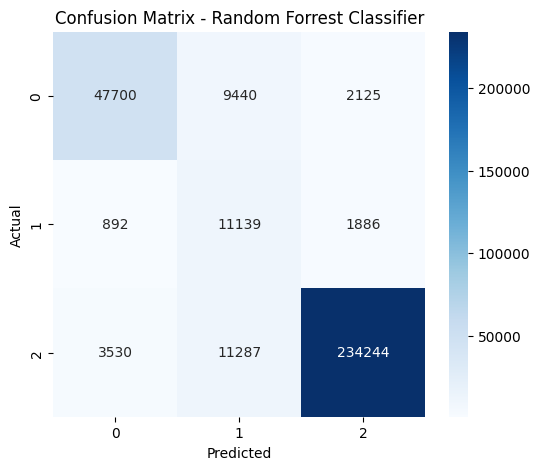

In [70]:
cm = confusion_matrix(y_train, x_predict_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forrest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
X_train.head()

,education,monthly_salary,company_type,house_type,family_size,dependents,current_emi_amount,credit_score,bank_balance,emergency_fund,...,expense_to_income_ratio,affordability_ratio,credit_score_numeric,combined_credit_risk,employment_tenure_category,is_long_term_employed,income_per_family_member,savings_to_income_ratio,credit_stability_score,loan_affordability_index
357047,1.0,10.254180,2.0,2.0,3,2,0.000000,699.0,-1.371876,-1.760172,...,997.190161,-996.190161,1,1,1.0,0,3.418060,-0.305441,1138.839137,1.115678
386311,1.0,9.903538,2.0,2.0,2,1,8.243019,765.0,-0.276021,-0.224999,...,2.298869,-2.131200,0,1,1.0,0,4.951769,-0.050590,1097.839662,1.301216
106376,1.0,10.927753,4.0,1.0,3,2,0.000000,658.0,0.130132,0.617183,...,972.526572,-971.526572,2,2,0.0,0,3.642584,0.068387,548.054203,1.097697
188259,0.0,10.379753,0.0,0.0,1,0,0.000000,731.0,-0.899229,-0.955291,...,2.417347,-1.417347,1,1,1.0,1,10.379753,-0.178667,1501.564449,1.199733
355920,1.0,11.021919,2.0,1.0,1,0,9.137877,801.0,-0.423670,-0.979020,...,2.254416,-2.083480,0,1,0.0,0,11.021919,-0.127264,324.777552,1.099872


In [92]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))


                     Feature  Importance
29  loan_affordability_index    0.136674
6         current_emi_amount    0.118899
3                 house_type    0.106686
23      combined_credit_risk    0.087984
21       affordability_ratio    0.072885
12          requested_tenure    0.068792
18      debt_to_income_ratio    0.055532
1             monthly_salary    0.043954
20   expense_to_income_ratio    0.042610
11          requested_amount    0.032529


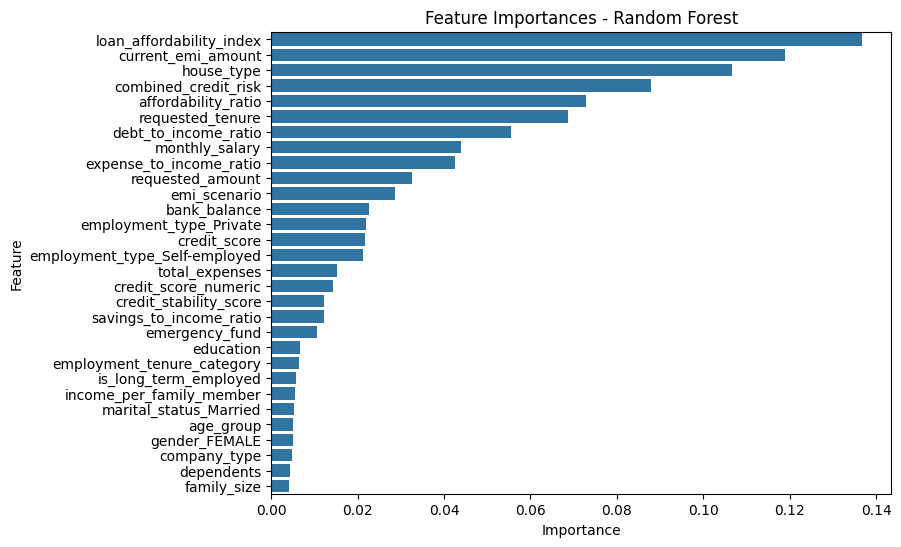

In [93]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importances - Random Forest")
plt.show()


In [94]:
# Check how many Class 0 people have existing loans vs Class 1
print(pd.crosstab(df['existing_loans'], df['emi_eligibility'], normalize='columns'))

emi_eligibility      0.0       1.0       2.0
existing_loans                              
0                0.84231  0.780064  0.533531
1                0.15769  0.219936  0.466469


2026/02/25 23:55:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\RAM\miniconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


🏃 View run gaudy-sponge-731 at: http://127.0.0.1:5000/#/experiments/8/runs/c29794a42ecf46d59491ca0616c72894
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8


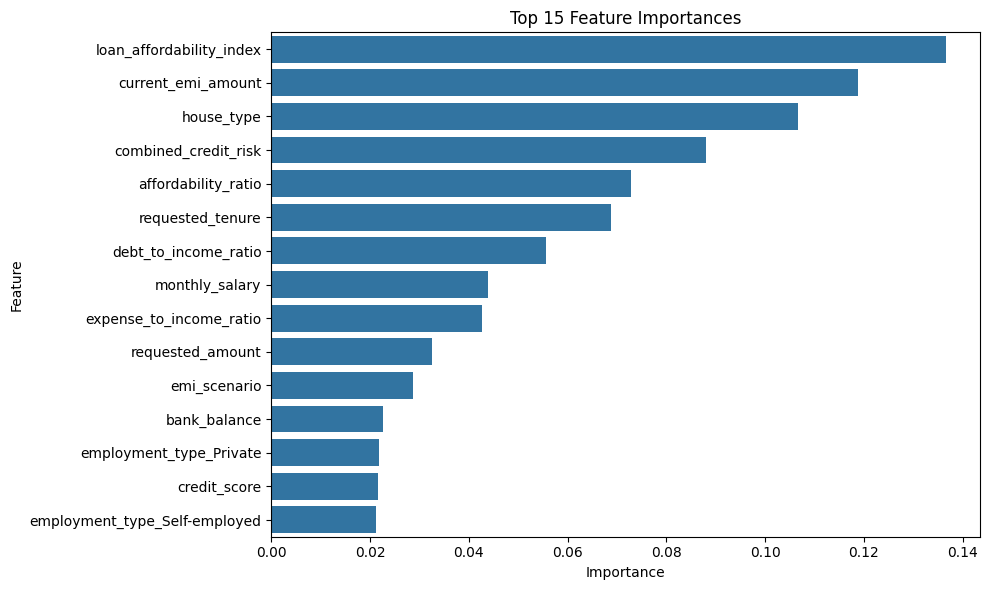

In [95]:
mlflow.set_experiment("EMI Eligibility Prediction XG Boost Classification experiment")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
with mlflow.start_run():

    # ---------------------
    # Log Parameters
    # ---------------------
    mlflow.log_param("model_type", "XGBoost Classifier")
    params = {
    "objective":'multi:softprob',
    "num_class":3,
    "n_estimators":1000,        
    "learning_rate":0.02,       
    "max_depth":6,              
    "reg_lambda":10.0,          
    "reg_alpha":1.0,            
    "subsample":0.8,            
    "colsample_bytree":0.8,     
    "min_child_weight":5,       
    "tree_method":'hist',       
    "random_state":42,
    "n_jobs":-1
    }
    mlflow.log_params(params)

    # ---------------------
    # Log Metrics
    # ---------------------
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1 score",f1)
    roc_auc_macro = roc_auc_score(
        label_binarize(y_test, classes=[0,1,2]),
        y_probs,
        average="macro"
    )
    mlflow.log_metric("roc_auc_macro", roc_auc_macro)

    # ---------------------
    # Confusion Matrix Plot
    # ---------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    plt.close()

    # ---------------------
    # ROC Curve (Multiclass)
    # ---------------------
    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    plt.figure(figsize=(7,6))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], linestyle='--')
    plt.title("Multiclass ROC Curve")
    plt.legend()

    plt.savefig("roc_curve.png")
    mlflow.log_artifact("roc_curve.png")
    plt.close()
   
    
    # 1. Log the DataFrame as a CSV Artifact
    csv_path = "feature_importance_xg_boost.csv"
    feature_importance.to_csv(csv_path, index=False)
    mlflow.log_artifact(csv_path)
    
    # 2. Log the Top 5 features as Metrics (for easy UI comparison)
    top_5 = feature_importance.head(5)
    for index, row in top_5.iterrows():
        # Replaces spaces with underscores for MLflow compatibility
        metric_name = f"feat_{row['Feature'].replace(' ', '_')}"
        mlflow.log_metric(metric_name, row['Importance'])

    # 3. Create and log a visual plot (The 'Quick Look')
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance.head(15))
    plt.title("Top 15 Feature Importances")
    plt.tight_layout()
    
    plot_path = "feature_importance_plot.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)

    # ---------------------
    # Log Model
    # ---------------------
    mlflow.sklearn.log_model(xgb_model, "XG Boost model")
